## 📊 أسئلة التحليل الرئيسية (Analytical Questions)

1. **ما هي الفئة (Category) الأكثر تحقيقاً للمبيعات والأرباح مقارنة بباقي الفئات؟**
2. **كيف تتوزع المبيعات شهرياً وسنوياً، وهل توجد مواسم معينة تشهد ارتفاعاً ملحوظاً في الطلب؟**
3. **ما هي العلاقة الفعلية بين حجم المبيعات وقيمة الأرباح (هل ارتفاع المبيعات يضمن بالضرورة تحقيق أرباح عالية؟)**
4. **ما هي المناطق الجغرافية أو المدن الأكثر نشاطاً في عدد الطلبات وإجمالي العوائد المالية؟**
5. **ما هي نسب هامش الربح (Profit Margin) لمختلف المنتجات، وهل توجد منتجات تباع بخسارة؟**
6. **ما هو متوسط مدة الشحن (Shipping Duration) وهل تؤثر سرعة الشحن على تقييم أو حجم المبيعات؟**
7. **كيف يتم تصنيف العملاء بناءً على حجم شرائهم (فئات الأداء: Low, Medium, High)، ومن هي الفئة الأكثر تأثيراً في الأرباح؟**
8. **ما هي وسائل الشحن الأكثر استخداماً من قبل الشركة، وما تكلفتها أو تأثيرها على الأداء التشغيلي؟**
9. **هل توجد قيم شاذة (Outliers) متطرفة في المبيعات أو الخصومات، وكيف تؤثر على دقة التحليل العام؟**
10. **ما هي التوصيات الاستراتيجية الممكن تقديمها للإدارة لزيادة الأرباح وتقليل التكاليف التشغيلية بناءً على البيانات؟**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")
file_path = r'C:\Users\Gaser\Desktop\Sample-Superstore2019.csv'
try:
    df = pd.read_csv(file_path)
    print("تم تحميل البيانات بنجاح ")
except Exception as e:
    print(f"حدث خطأ أثناء تحميل الملف: {e}")
if 'df' in locals():
    display(df.head())
    print("\n--- معلومات الداتا فريم ---")
    df.info()

تم تحميل البيانات بنجاح 


,Unnamed: 0,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164



--- معلومات الداتا فريم ---
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9994 non-null   int64  
 1   Row ID          9994 non-null   int64  
 2   Order ID        9994 non-null   str    
 3   Order Date      9994 non-null   str    
 4   Ship Date       9994 non-null   str    
 5   Ship Mode       9994 non-null   str    
 6   Customer ID     9994 non-null   str    
 7   Customer Name   9994 non-null   str    
 8   Segment         9994 non-null   str    
 9   Country/Region  9994 non-null   str    
 10  City            9994 non-null   str    
 11  State           9994 non-null   str    
 12  Postal Code     9983 non-null   float64
 13  Region          9994 non-null   str    
 14  Product ID      9994 non-null   str    
 15  Category        9994 non-null   str    
 16  Sub-Category    9994 non-null   str    
 17  Product Name   

In [3]:
def clean_and_preprocess_data(dataframe):
    """
    دالة موحدة لتنظيف البيانات ومعالجة القيم المفقودة والتكرارات بشكل متوافق تماماً.
    """
    cleaned_df = dataframe.copy()
    initial_rows = len(cleaned_df)
    cleaned_df.drop_duplicates(inplace=True)
    duplicates_removed = initial_rows - len(cleaned_df)
    print(f"تم إزالة {duplicates_removed} سجل مكرر بنجاح.")
    date_columns = ['Order Date', 'Ship Date']
    for col in date_columns:
        if col in cleaned_df.columns:
            cleaned_df[col] = pd.to_datetime(cleaned_df[col], errors='coerce')
    for col in cleaned_df.columns:
        if cleaned_df[col].dtype == 'object' or pd.api.types.is_string_dtype(cleaned_df[col]):
            cleaned_df[col] = cleaned_df[col].fillna('Unknown')
        elif pd.api.types.is_numeric_dtype(cleaned_df[col]):
            cleaned_df[col] = cleaned_df[col].fillna(cleaned_df[col].median())        
    print("تم الانتهاء من تنظيف البيانات ومعالجة القيم المفقودة بنجاح")
    return cleaned_df
df_cleaned = clean_and_preprocess_data(df)
print("\n--- معلومات الداتا بعد التنظيف ---")
df_cleaned.info()

تم إزالة 0 سجل مكرر بنجاح.
تم الانتهاء من تنظيف البيانات ومعالجة القيم المفقودة بنجاح

--- معلومات الداتا بعد التنظيف ---
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Unnamed: 0      9994 non-null   int64         
 1   Row ID          9994 non-null   int64         
 2   Order ID        9994 non-null   str           
 3   Order Date      9994 non-null   datetime64[us]
 4   Ship Date       9994 non-null   datetime64[us]
 5   Ship Mode       9994 non-null   str           
 6   Customer ID     9994 non-null   str           
 7   Customer Name   9994 non-null   str           
 8   Segment         9994 non-null   str           
 9   Country/Region  9994 non-null   str           
 10  City            9994 non-null   str           
 11  State           9994 non-null   str           
 12  Postal Code     9994 non-null   float64       
 1

In [ ]:
def optimize_and_handle_outliers(dataframe):
    df_processed = dataframe.copy()
    for col in df_processed.select_dtypes(include=['object', 'str']).columns:
        num_unique = len(df_processed[col].unique())
        num_total = len(df_processed[col])
        if num_unique / num_total < 0.5:
            df_processed[col] = df_processed[col].astype('category')
    if 'Sales' in df_processed.columns:
        Q1 = df_processed['Sales'].quantile(0.25)
        Q3 = df_processed['Sales'].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_processed = df_processed[(df_processed['Sales'] >= lower_bound) & (df_processed['Sales'] <= upper_bound)] 
    print("تم تحسين الذاكرة ومعالجة القيم الشاذة بنجاح")
    return df_processed
df_final = optimize_and_handle_outliers(df_cleaned)

تم تحسين الذاكرة ومعالجة القيم الشاذة بنجاح


In [11]:

print("="*40)
print(" 📊 Automated KPI Summary Report ")
print("="*40)
print(f"Total Sales: ${df_final['Sales'].sum():,.2f}")
print(f"Total Profit: ${df_final['Profit'].sum():,.2f}")
print(f"Average Profit Margin: {df_final['Profit Margin'].mean():.2%}")
print(f"Average Shipping Duration: {df_final['Shipping Duration'].mean():.1f} days")
print(f"Total Records After Processing: {len(df_final):,}")
print("="*40)

 📊 Automated KPI Summary Report 
Total Sales: $376,704.44
Total Profit: $60,670.67
Average Profit Margin: 12.97%
Average Shipping Duration: 4.0 days
Total Records After Processing: 7,458


C:\Users\NEXT STORE\AppData\Local\Temp\ipykernel_17200\316206725.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='Category', y='Sales', estimator=sum, palette='Blues_d')
C:\Users\NEXT STORE\AppData\Local\Temp\ipykernel_17200\316206725.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x='Region', palette='Set2')
C:\Users\NEXT STORE\AppData\Local\Temp\ipykernel_17200\316206725.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='Category', y='Profit Margin', estimator=np.mean, palette=

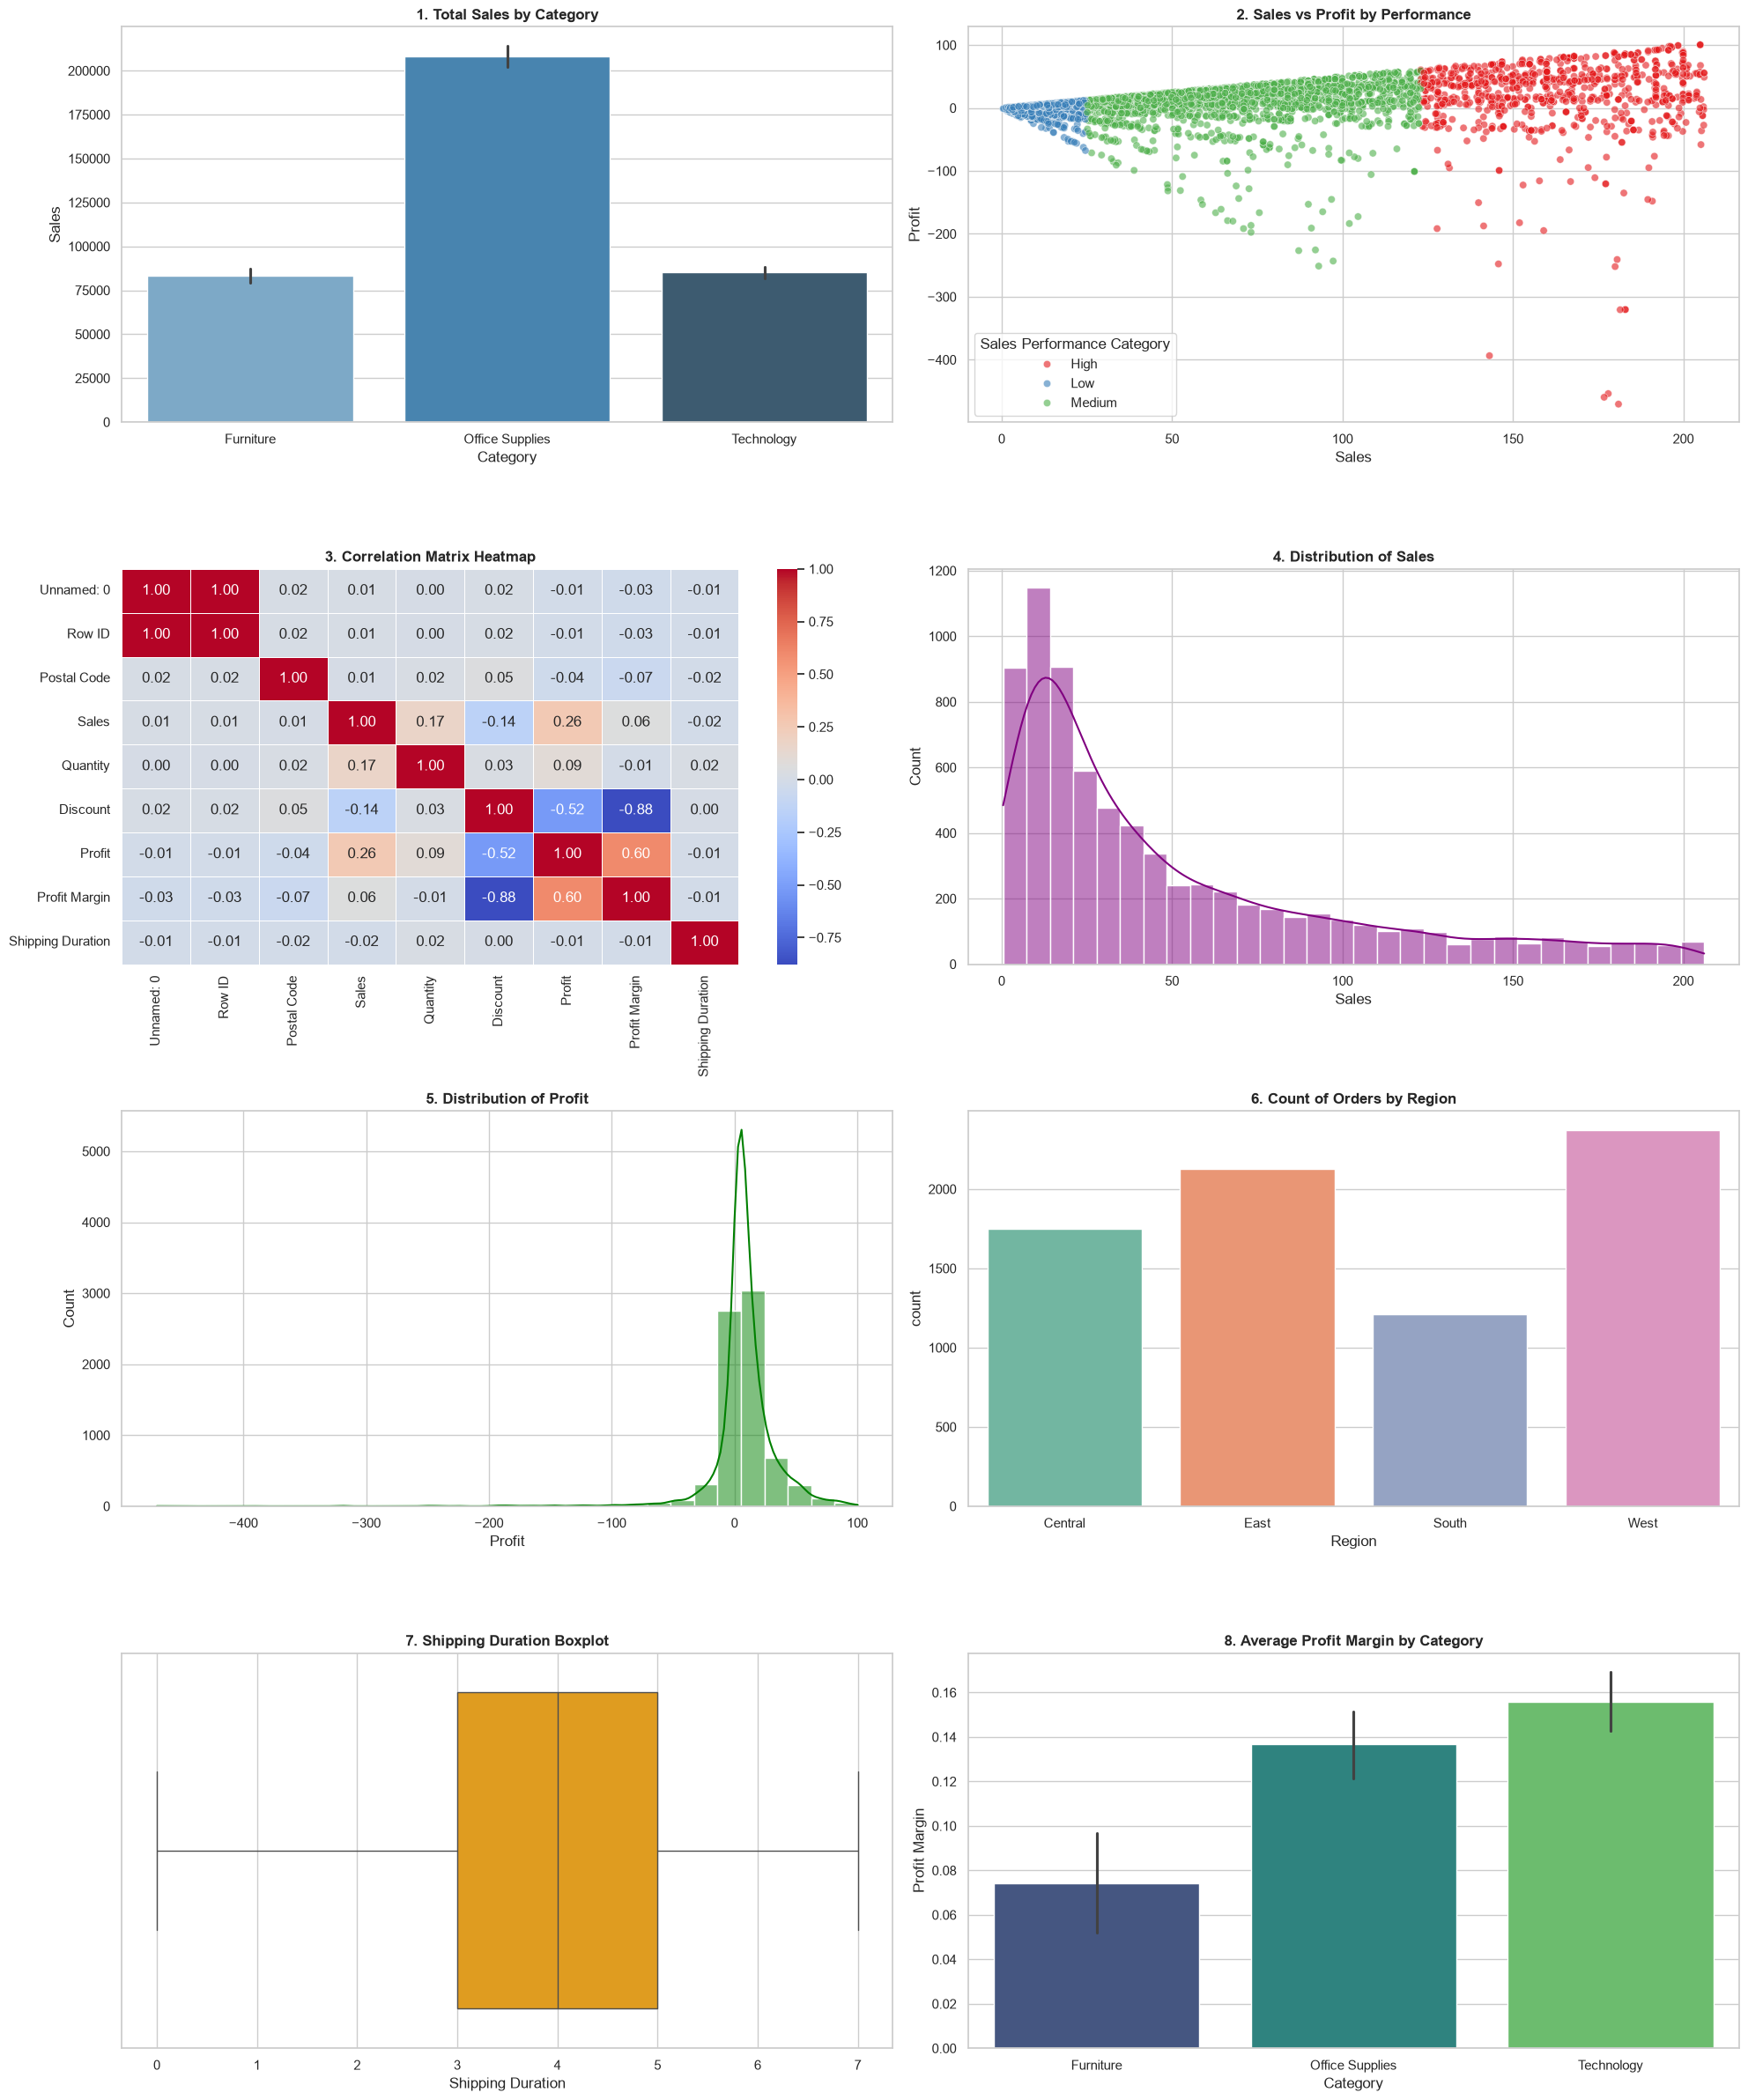

In [13]:
plt.figure(figsize=(20, 24))
plt.subplot(4, 2, 1)
sns.barplot(data=df_final, x='Category', y='Sales', estimator=sum, palette='Blues_d')
plt.title('1. Total Sales by Category', fontsize=12, fontweight='bold')
plt.subplot(4, 2, 2)
sns.scatterplot(data=df_final, x='Sales', y='Profit', hue='Sales Performance Category', palette='Set1', alpha=0.6)
plt.title('2. Sales vs Profit by Performance', fontsize=12, fontweight='bold')
plt.subplot(4, 2, 3)
numeric_df = df_final.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('3. Correlation Matrix Heatmap', fontsize=12, fontweight='bold')
plt.subplot(4, 2, 4)
sns.histplot(df_final['Sales'], bins=30, kde=True, color='purple')
plt.title('4. Distribution of Sales', fontsize=12, fontweight='bold')
plt.subplot(4, 2, 5)
sns.histplot(df_final['Profit'], bins=30, kde=True, color='green')
plt.title('5. Distribution of Profit', fontsize=12, fontweight='bold')
plt.subplot(4, 2, 6)
sns.countplot(data=df_final, x='Region', palette='Set2')
plt.title('6. Count of Orders by Region', fontsize=12, fontweight='bold')
plt.subplot(4, 2, 7)
sns.boxplot(data=df_final, x='Shipping Duration', color='orange')
plt.title('7. Shipping Duration Boxplot', fontsize=12, fontweight='bold')
plt.subplot(4, 2, 8)
sns.barplot(data=df_final, x='Category', y='Profit Margin', estimator=np.mean, palette='viridis')
plt.title('8. Average Profit Margin by Category', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
def engineer_features(dataframe):
    """
    دالة لهندسة الميزات (Feature Engineering) المطلوبة.
    """
    df_eng = dataframe.copy()
    df_eng['Profit Margin'] = np.where(df_eng['Sales'] != 0, df_eng['Profit'] / df_eng['Sales'], 0)
    df_eng['Shipping Duration'] = (df_eng['Ship Date'] - df_eng['Order Date']).dt.days
    sales_q1 = df_eng['Sales'].quantile(0.33)
    sales_q2 = df_eng['Sales'].quantile(0.66)
    def classify_sales(sales):
        if sales < sales_q1:
            return 'Low'
        elif sales < sales_q2:
            return 'Medium'
        else:
            return 'High'         
    df_eng['Sales Performance Category'] = df_eng['Sales'].apply(classify_sales)   
    print("تم إنشاء الميزات الجديدة بنجاح")
    return df_eng
df_final = engineer_features(df_cleaned)
print("\n--- عينة من البيانات بعد إضافة الأعمدة الجديدة ---")
display(df_final[['Sales', 'Profit', 'Profit Margin', 'Shipping Duration', 'Sales Performance Category']].head())

تم إنشاء الميزات الجديدة بنجاح

--- عينة من البيانات بعد إضافة الأعمدة الجديدة ---


,Sales,Profit,Profit Margin,Shipping Duration,Sales Performance Category
0,261.9600,41.9136,0.1600,3,High
1,731.9400,219.5820,0.3000,3,High
2,14.6200,6.8714,0.4700,4,Low
3,957.5775,-383.0310,-0.4000,7,High
4,22.3680,2.5164,0.1125,7,Low


--- الإحصائيات الوصفية للأعمدة الرقمية ---


,Unnamed: 0,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Profit Margin,Shipping Duration
count,9994.000000,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4996.500000,4997.500000,2018-04-30 10:03:51.979187,2018-05-04 09:03:29.645787,55247.278067,229.858001,3.789574,0.156203,28.656896,0.120314,3.958075
min,0.000000,1.000000,2016-01-03 00:00:00,2016-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,-2.750000,0.000000
25%,2498.250000,2499.250000,2017-05-23 00:00:00,2017-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,0.075000,3.000000
50%,4996.500000,4997.500000,2018-06-26 00:00:00,2018-06-29 00:00:00,57103.000000,54.490000,3.000000,0.200000,8.666500,0.270000,4.000000
75%,7494.750000,7495.750000,2019-05-14 00:00:00,2019-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,0.362500,5.000000
max,9993.000000,9994.000000,2019-12-30 00:00:00,2020-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,0.500000,7.000000
std,2885.163629,2885.163629,NaN,NaN,32021.136719,623.245101,2.225110,0.206452,234.260108,0.466754,1.747937


C:\Users\NEXT STORE\AppData\Local\Temp\ipykernel_17200\3093977025.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_sales, x='Category', y='Sales', palette='Blues_d')


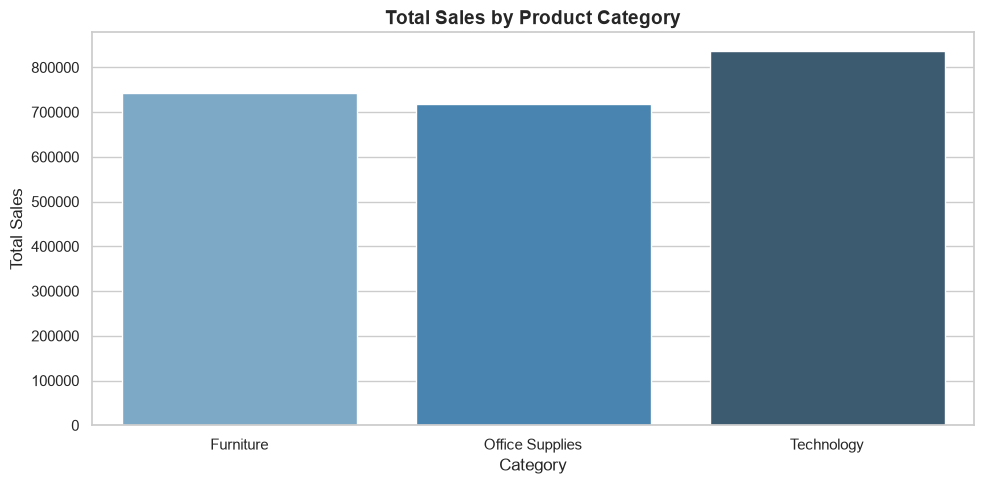

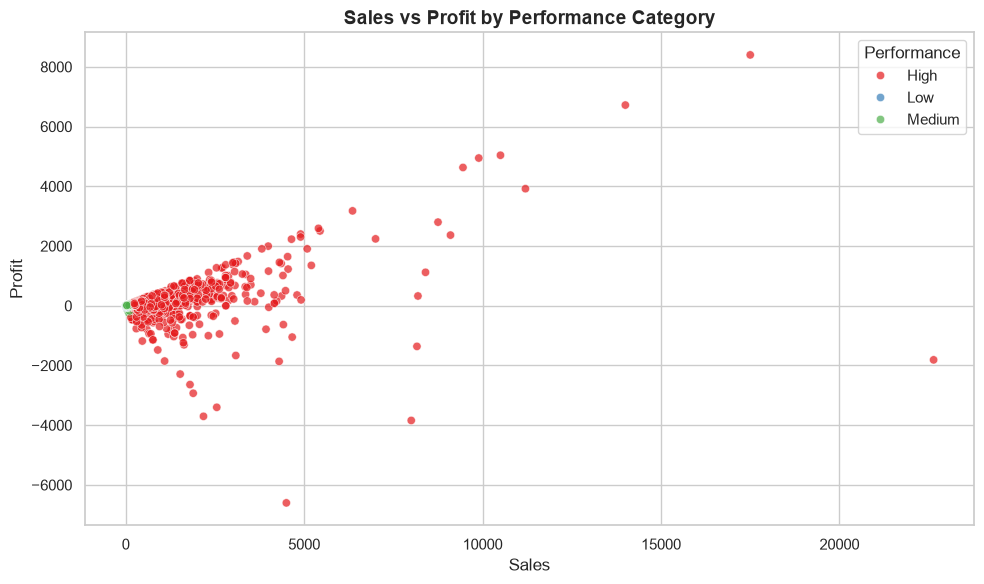

In [5]:

print("--- الإحصائيات الوصفية للأعمدة الرقمية ---")
display(df_final.describe())
plt.figure(figsize=(10, 5))
category_sales = df_final.groupby('Category')['Sales'].sum().reset_index()
sns.barplot(data=category_sales, x='Category', y='Sales', palette='Blues_d')
plt.title('Total Sales by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_final, 
    x='Sales', 
    y='Profit', 
    hue='Sales Performance Category', 
    palette='Set1', 
    alpha=0.7
)
plt.title('Sales vs Profit by Performance Category', fontsize=14, fontweight='bold')
plt.xlabel('Sales', fontsize=12)
plt.ylabel('Profit', fontsize=12)
plt.legend(title='Performance')
plt.tight_layout()
plt.show()

In [6]:

output_file = 'Cleaned_Superstore_Data.csv'

try:
    df_final.to_csv(output_file, index=False)
    print(f"تم حفظ الملف بنجاح باسم: '{output_file}' في نفس مجلد العمل")
except Exception as e:
    print(f"حدث خطأ أثناء حفظ الملف: {e}")
print(f"إجمالي عدد الصفوف النهائية بعد التنظيف: {df_final.shape[0]}")
print(f"إجمالي عدد الأعمدة (شاملة الميزات الجديدة): {df_final.shape[1]}")

تم حفظ الملف بنجاح باسم: 'Cleaned_Superstore_Data.csv' في نفس مجلد العمل
إجمالي عدد الصفوف النهائية بعد التنظيف: 9994
إجمالي عدد الأعمدة (شاملة الميزات الجديدة): 25
